In [1]:
import os
os.environ["KAGGLE_TOKEN"] = "KGAT_4722d2b7b32a2b88427663996bc3365a"

!pip install kaggle -q

import pandas as pd

!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -q creditcardfraud.zip

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:04<00:00, 14.8MB/s]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

import warnings
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv("creditcard.csv")

print("Shape:", df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())
print("\nClass distribution:")
print(df["Class"].value_counts())
print(f"\nFraud rate: {df['Class'].mean()*100:.3f}%")


Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26 

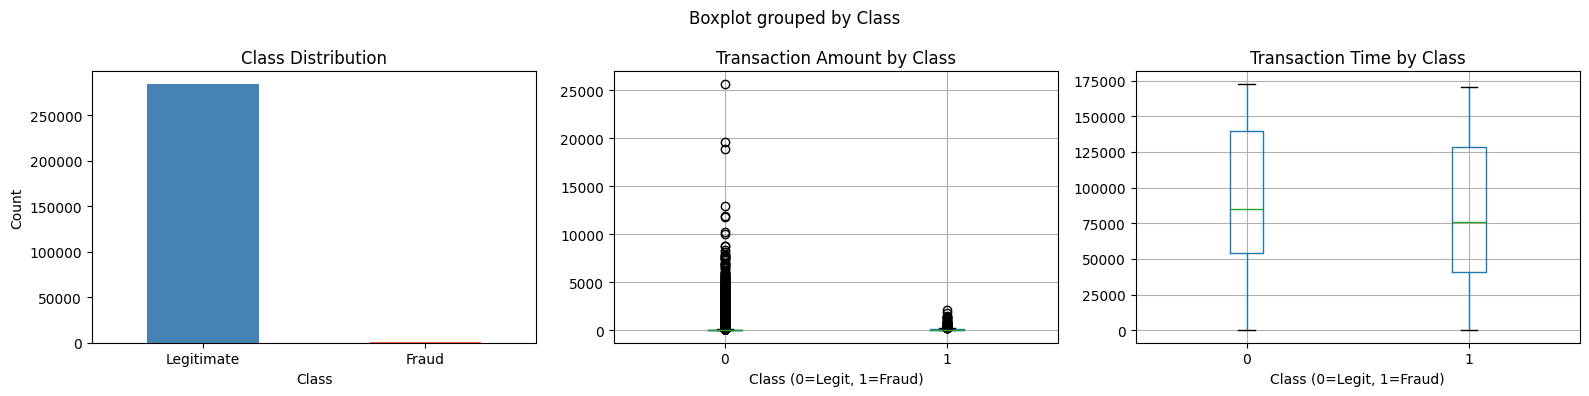

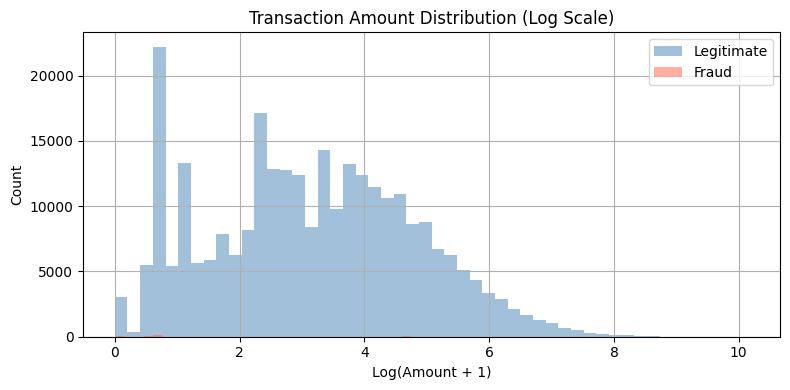

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
df["Class"].value_counts().plot.bar(ax=axes[0], color=["steelblue", "tomato"])
axes[0].set_title("Class Distribution")
axes[0].set_xticklabels(["Legitimate", "Fraud"], rotation=0)
axes[0].set_ylabel("Count")

# Transaction amount by class
df.boxplot(column="Amount", by="Class", ax=axes[1])
axes[1].set_title("Transaction Amount by Class")
axes[1].set_xlabel("Class (0=Legit, 1=Fraud)")

# Transaction time by class
df.boxplot(column="Time", by="Class", ax=axes[2])
axes[2].set_title("Transaction Time by Class")
axes[2].set_xlabel("Class (0=Legit, 1=Fraud)")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150)
plt.show()

# Amount distribution (log scale) for fraud vs legit
plt.figure(figsize=(8, 4))
df[df["Class"] == 0]["Amount"].apply(np.log1p).hist(bins=50, alpha=0.5, label="Legitimate", color="steelblue")
df[df["Class"] == 1]["Amount"].apply(np.log1p).hist(bins=50, alpha=0.5, label="Fraud", color="tomato")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Count")
plt.title("Transaction Amount Distribution (Log Scale)")
plt.legend()
plt.tight_layout()
plt.savefig("amount_distribution.png", dpi=150)
plt.show()



In [5]:
# Only Amount and Time need scaling — V1-V28 are already PCA-transformed
df["Amount_scaled"] = StandardScaler().fit_transform(df[["Amount"]])
df["Time_scaled"]   = StandardScaler().fit_transform(df[["Time"]])
df.drop(columns=["Amount", "Time"], inplace=True)

X = df.drop(columns=["Class"])
y = df["Class"]

# Strict train/test split BEFORE any fitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Train fraud rate: {y_train.mean()*100:.3f}%")
print(f"Test fraud rate: {y_test.mean()*100:.3f}%")




Train size: 227845 | Test size: 56962
Train fraud rate: 0.173%
Test fraud rate: 0.172%


In [6]:
# Applied AFTER train/test split to prevent leakage
print("\nBefore SMOTE:", y_train.value_counts().to_dict())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("After SMOTE:", pd.Series(y_train_res).value_counts().to_dict())



Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


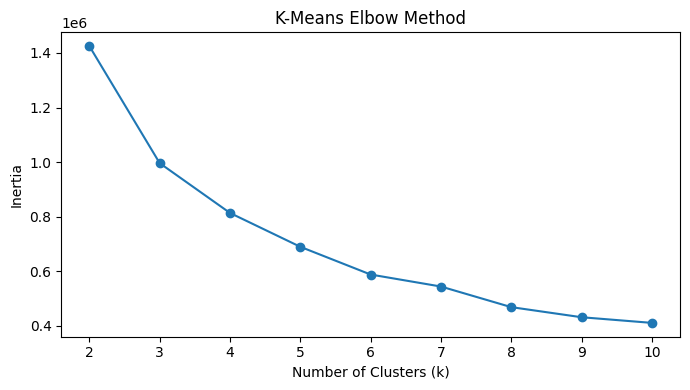

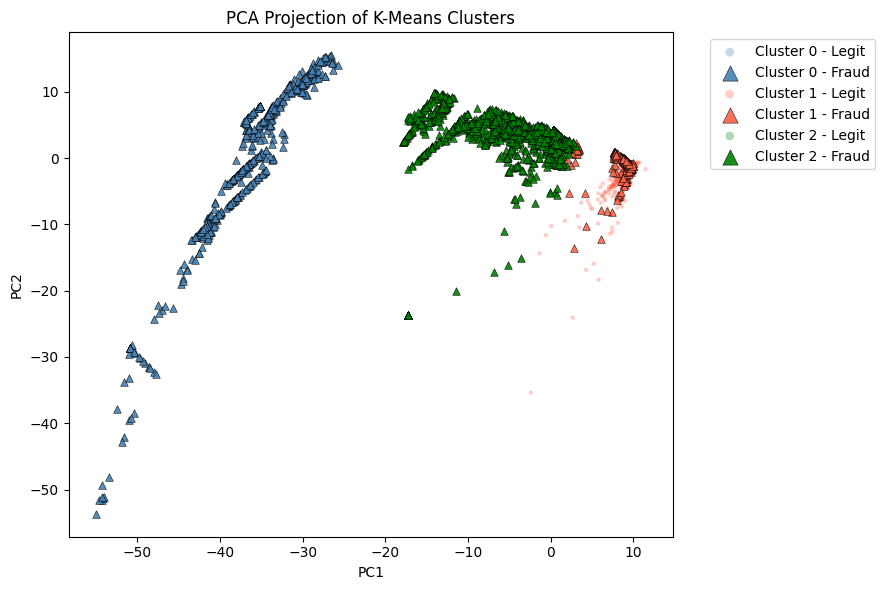


Fraud rate per cluster:
cluster
0    0.9997
1    0.1770
2    0.9998
Name: fraud, dtype: float64


In [14]:
# Run on resampled training data (post-SMOTE)
# Subsample for speed since dataset is large
sample_idx = np.random.choice(len(X_train_res), size=10000, replace=False)
X_sample = X_train_res.iloc[sample_idx] if hasattr(X_train_res, 'iloc') else X_train_res[sample_idx]

# Elbow method
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, marker="o")
plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig("kmeans_elbow.png", dpi=150)
plt.show()

# Fit with optimal k
OPTIMAL_K = 3
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train_res if not hasattr(X_train_res, 'values') else X_train_res)
test_clusters  = kmeans.predict(X_test)

# Append cluster label as a new feature
if hasattr(X_train_res, 'values'):
    X_train_with_cluster = np.hstack([X_train_res.values, train_clusters.reshape(-1, 1)])
    X_test_with_cluster  = np.hstack([X_test.values,      test_clusters.reshape(-1, 1)])
else:
    X_train_with_cluster = np.hstack([X_train_res, train_clusters.reshape(-1, 1)])
    X_test_with_cluster  = np.hstack([X_test,      test_clusters.reshape(-1, 1)])

# PCA visualization
# PCA visualization
pca = PCA(n_components=2, random_state=42)
vis_idx = np.random.choice(len(X_train_with_cluster), size=5000, replace=False)
X_pca = pca.fit_transform(X_train_with_cluster[vis_idx])
vis_clusters = train_clusters[vis_idx]
vis_labels   = y_train_res.iloc[vis_idx] if hasattr(y_train_res, 'iloc') else y_train_res[vis_idx]

fraud_mask = np.array(vis_labels) == 1
colors = ["steelblue", "tomato", "green"]

plt.figure(figsize=(9, 6))
for cluster_id in range(OPTIMAL_K):
    cluster_mask = vis_clusters == cluster_id
    mask_legit = cluster_mask & ~fraud_mask
    mask_fraud = cluster_mask & fraud_mask
    plt.scatter(X_pca[mask_legit, 0], X_pca[mask_legit, 1],
                color=colors[cluster_id], marker="o", s=10, alpha=0.3,
                edgecolors="none", label=f"Cluster {cluster_id} - Legit")
    plt.scatter(X_pca[mask_fraud, 0], X_pca[mask_fraud, 1],
                color=colors[cluster_id], marker="^", s=30, alpha=0.9,
                edgecolors="black", linewidths=0.4, label=f"Cluster {cluster_id} - Fraud")

plt.title("PCA Projection of K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

# Fraud rate per cluster
cluster_fraud = pd.DataFrame({
    "cluster": train_clusters,
    "fraud": y_train_res.values if hasattr(y_train_res, 'values') else y_train_res
})
print("\nFraud rate per cluster:")
print(cluster_fraud.groupby("cluster")["fraud"].mean().round(4))



In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "XGBoost":             xgb.XGBClassifier(
                               n_estimators=200,
                               learning_rate=0.05,
                               max_depth=5,
                               subsample=0.8,
                               colsample_bytree=0.8,
                               use_label_encoder=False,
                               eval_metric="logloss",
                               random_state=42
                           )
}

results = {}

for name, model in models.items():
    model.fit(X_train_with_cluster, y_train_res)
    y_pred  = model.predict(X_test_with_cluster)
    y_proba = model.predict_proba(X_test_with_cluster)[:, 1]

    results[name] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
        "Avg Precision": average_precision_score(y_test, y_proba)
    }
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"]))

results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df.round(4))



  Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


  XGBoost
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.24      0.87      0.38        98

    accuracy                           1.00     56962
   macro avg       0.62      0.93      0.69     56962
weighted avg       1.00      1.00      1.00     56962


Model Comparison:
                     Accuracy      F1  ROC-AUC  Avg Precision
Logistic Regression    0.9742  0.1090   0.9699         0.7201
XGBoost                0.9951  0.3778   0.9795         0.8386


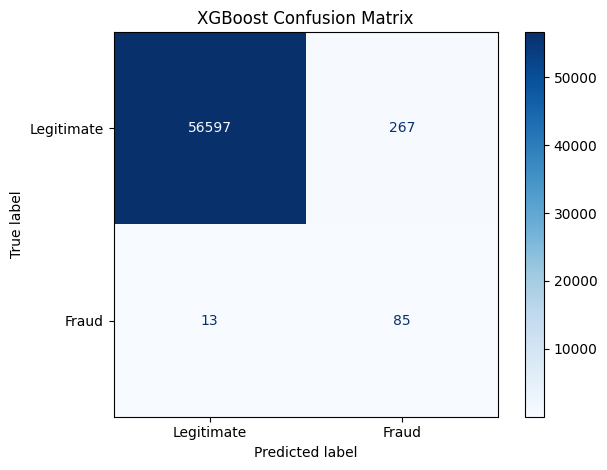

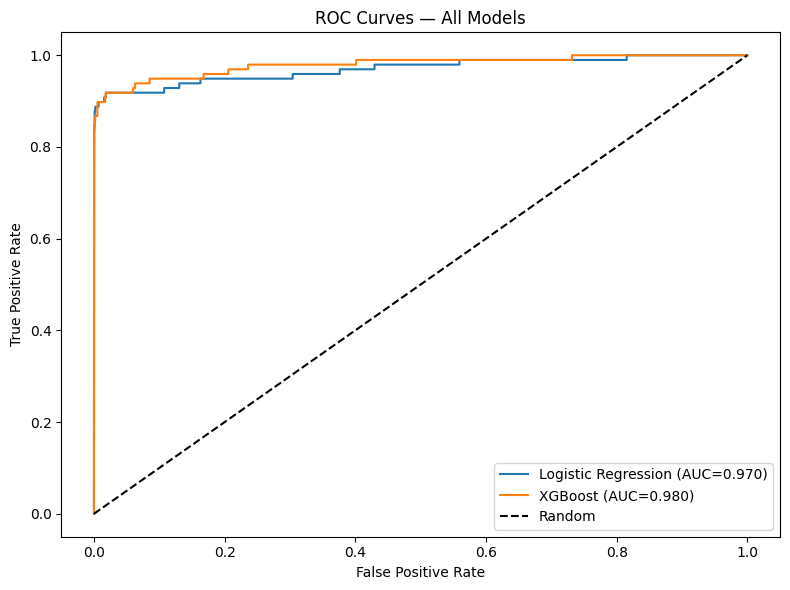

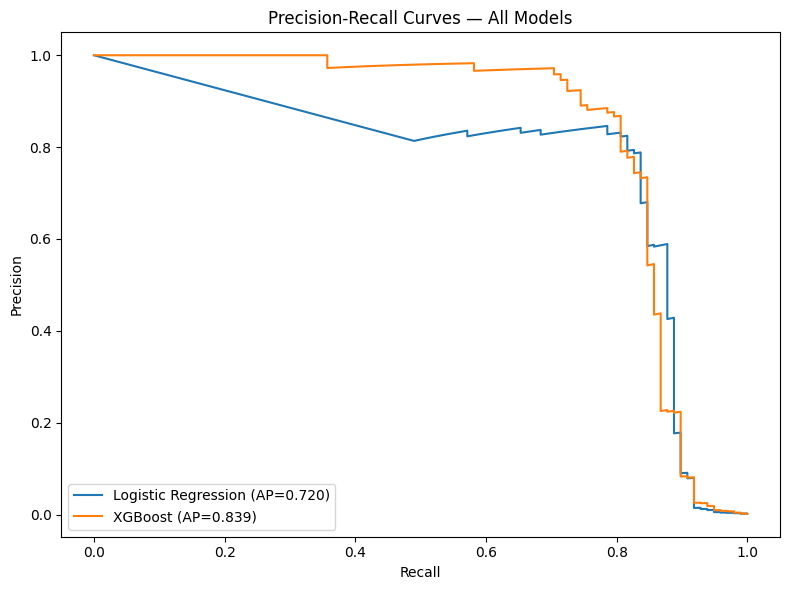

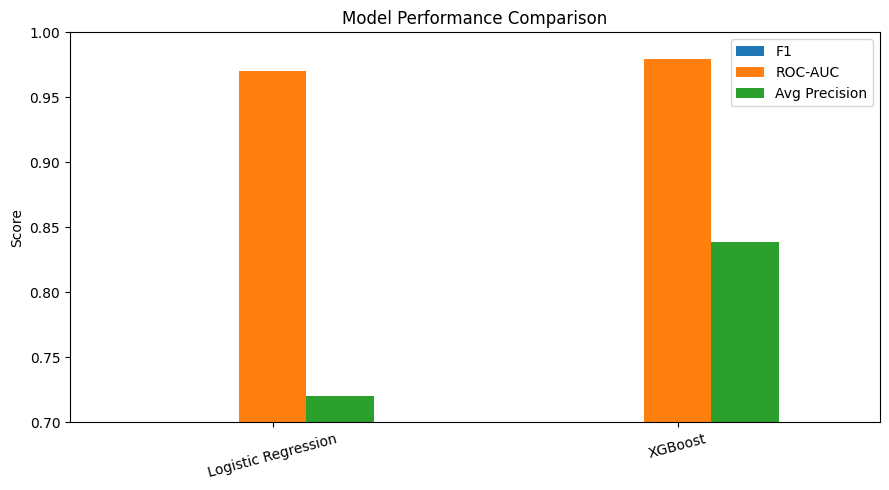

In [10]:
xgb_model = models["XGBoost"]
y_pred_xgb = xgb_model.predict(X_test_with_cluster)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
disp.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix_xgb.png", dpi=150)
plt.show()

# ROC curves
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_with_cluster)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

# Precision-Recall curves (more meaningful for extreme imbalance)
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_with_cluster)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — All Models")
plt.legend()
plt.tight_layout()
plt.savefig("precision_recall_curves.png", dpi=150)
plt.show()

# Metric bar chart
results_df[["F1", "ROC-AUC", "Avg Precision"]].plot(kind="bar", figsize=(9, 5), ylim=(0.7, 1.0))
plt.title("Model Performance Comparison")
plt.xticks(rotation=15)
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()


In [11]:
xgb_no_smote = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=5,
    use_label_encoder=False, eval_metric="logloss", random_state=42
)
# Train on original imbalanced data (with cluster feature)
X_train_orig_with_cluster = np.hstack([X_train.values, kmeans.predict(X_train).reshape(-1, 1)])
xgb_no_smote.fit(X_train_orig_with_cluster, y_train)
y_proba_no_smote = xgb_no_smote.predict_proba(X_test_with_cluster)[:, 1]

print("\n--- Ablation: SMOTE vs No SMOTE (XGBoost) ---")
print(f"With SMOTE    — ROC-AUC: {results['XGBoost']['ROC-AUC']:.4f} | AP: {results['XGBoost']['Avg Precision']:.4f}")
print(f"Without SMOTE — ROC-AUC: {roc_auc_score(y_test, y_proba_no_smote):.4f} | AP: {average_precision_score(y_test, y_proba_no_smote):.4f}")



--- Ablation: SMOTE vs No SMOTE (XGBoost) ---
With SMOTE    — ROC-AUC: 0.9795 | AP: 0.8386
Without SMOTE — ROC-AUC: 0.9775 | AP: 0.8759


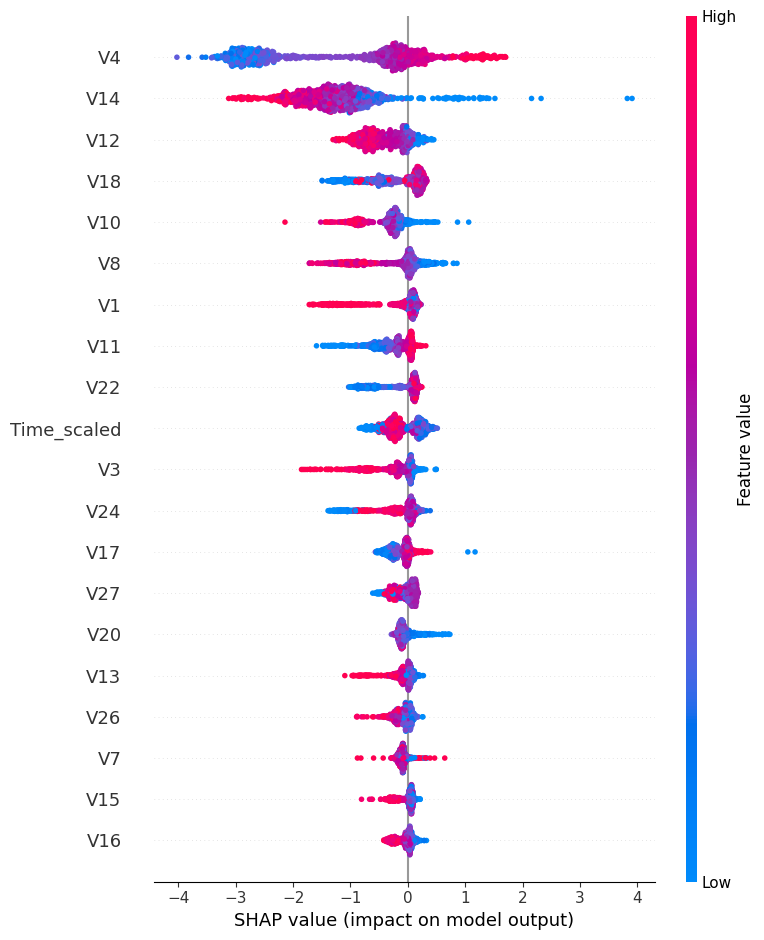

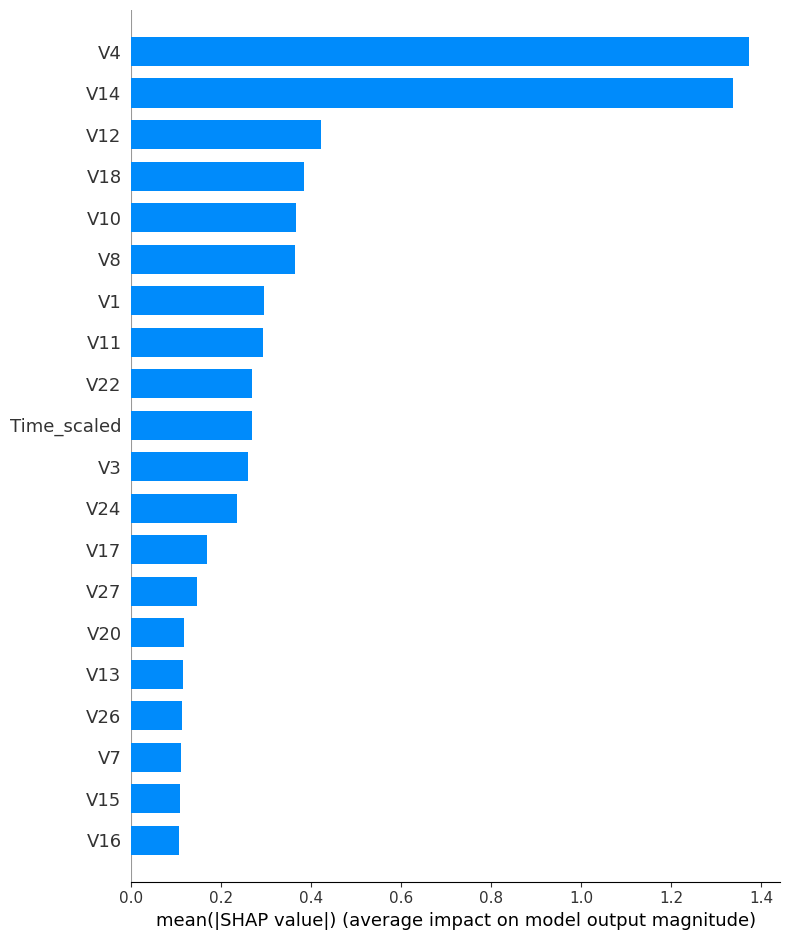

In [12]:
feature_names = list(X.columns) + ["kmeans_cluster"]

explainer   = shap.TreeExplainer(xgb_model)

# Subsample test set for speed
shap_idx    = np.random.choice(len(X_test_with_cluster), size=1000, replace=False)
shap_values = explainer.shap_values(X_test_with_cluster[shap_idx])

shap.summary_plot(shap_values, X_test_with_cluster[shap_idx],
                  feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150)
plt.show()

shap.summary_plot(shap_values, X_test_with_cluster[shap_idx],
                  feature_names=feature_names, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150)
plt.show()


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        use_label_encoder=False, eval_metric="logloss", random_state=42
    ),
    X_train_with_cluster, y_train_res,
    cv=cv, scoring="roc_auc"
)
print(f"\n5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


5-Fold CV ROC-AUC: 0.9999 ± 0.0000
